In [1]:
import sys, os, pickle, random

import numpy as np
import matplotlib.pyplot as plt
import pickle

from resplan_utils import (
    CATEGORY_COLORS,
    normalize_keys, get_plan_width,
    get_geometries, centroid,
    geometry_to_mask,
    augment_geom,
    buffer_shrink_expand, buffer_expand_shrink,
    plot_plan,
    plan_to_graph, plot_plan_and_graph
)

from resplan_utils import *

# plt.rcParams['figure.dpi'] = 110

In [2]:
# By default, we load from /mnt/data. Change DATA_PATH if needed.
DATA_PATH = 'ResPlan.pkl'

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

print(f'Loaded {len(plans)} plans')
# Peek at keys of the first plan
example = plans[0]
print('Sample keys:', list(example.keys())[:20])

# Normalize common key typos (e.g., balacony -> balcony) in-place for safety
for p in plans:
    normalize_keys(p)

Loaded 17107 plans
Sample keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'storage']


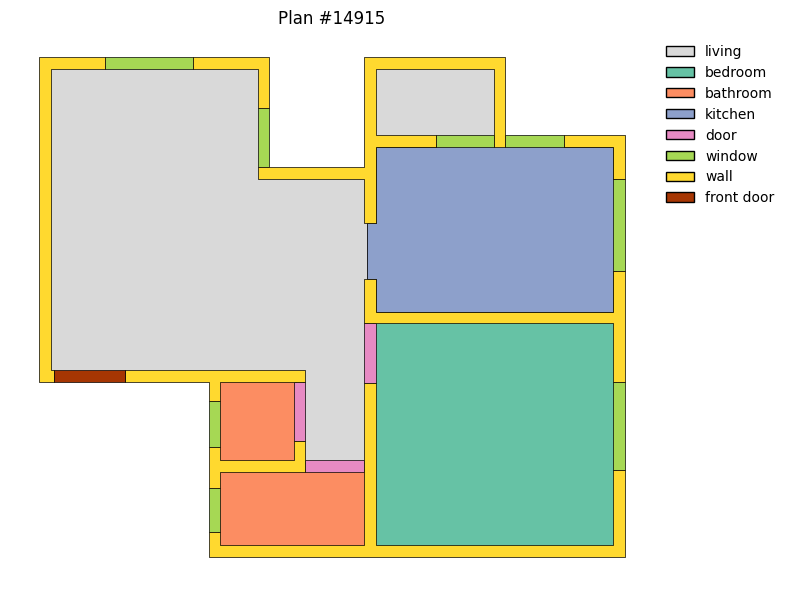

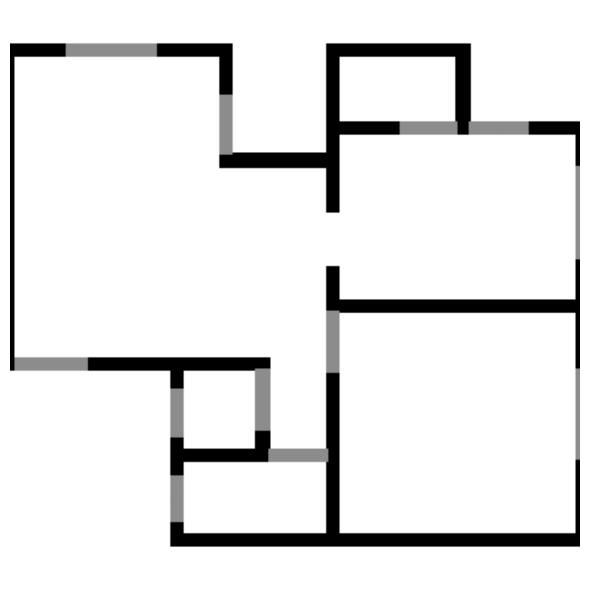

In [3]:
idx = random.randrange(len(plans))
plan = plans[idx]

ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()

img = get_2d_plan(plan, show=True)

/opt/dlami/nvme/mitunet_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/mitunet/seg_graph_worker.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setti

Total components found (excl. background): 10
  [KEEP] comp 1: area=  29272, bbox=(4,4,182,202)
  [KEEP] comp 2: area=  37366, bbox=(196,4,320,136)
  [KEEP] comp 3: area=  23975, bbox=(360,114,156,156)
  [KEEP] comp 4: area=  49344, bbox=(196,152,155,364)
  [KEEP] comp 5: area=   6999, bbox=(36,216,103,68)
  [KEEP] comp 6: area=   6719, bbox=(410,280,105,64)
  [KEEP] comp 7: area=  13334, bbox=(66,354,129,104)
  [KEEP] comp 8: area=  16179, bbox=(360,354,156,104)
  [KEEP] comp 9: area=   3767, bbox=(4,355,52,73)
  [KEEP] comp 10: area=   4004, bbox=(4,439,52,77)
Detected 10 rooms
  Room  1: bbox=(4, 4, 182, 202), centroid=(92, 122), area=29272
  Room  2: bbox=(196, 4, 320, 136), centroid=(343, 63), area=37366
  Room  3: bbox=(360, 114, 156, 156), centroid=(437, 190), area=23975
  Room  4: bbox=(196, 152, 155, 364), centroid=(271, 313), area=49344
  Room  5: bbox=(36, 216, 103, 68), centroid=(86, 249), area=6999
  Room  6: bbox=(410, 280, 105, 64), centroid=(462, 311), area=6719
  Room 

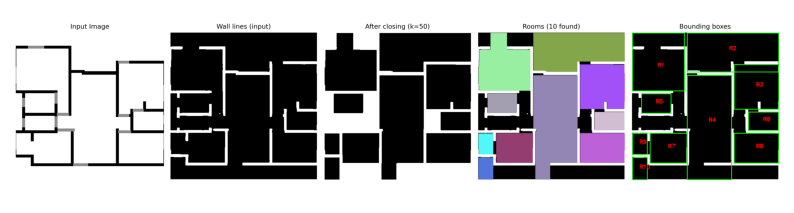

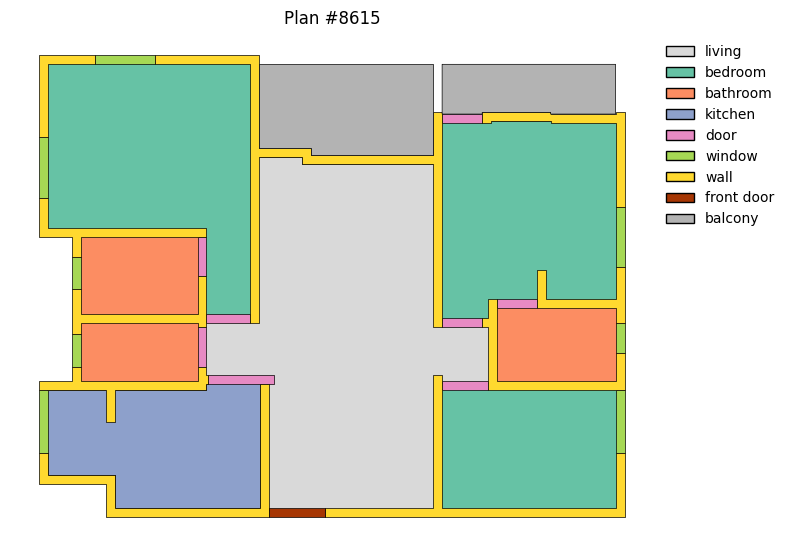

In [4]:
idx = random.randrange(len(plans))
plan = plans[idx]

SHAPE = (512, 512)

img = get_2d_plan(plan, show=False)
img_path = f'plans/plan_{idx}.png'
cv2.imwrite(img_path, img)

from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries

build_graph(img_path)
# plot room_detection.png image
img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()
